# Characterization & confusion analyses

Este notebook **centraliza** el código de las respuestas a los comentarios del revisor.
Ejecutar desde el directorio `notebooks/` (usa rutas relativas `../`). Requiere el `.venv` del proyecto (TF 2.19).

**Contenido**
1. Parámetros entrenables + FLOPs de las 4 arquitecturas — *reviewer comment 5*
2. F1 por especie desde Monte Carlo Dropout (figura) — *evaluación*
3. Matriz de confusión por familia filogenética — 667×667 (puntos intra/inter) + 36×36 agregada — *reviewer comment 8a*
4. Matriz de confianza bayesiana (MC Dropout) — 667×667 (intra/inter) + 36×36 agregada — *reviewer comment 8b*

**Salidas que genera** (todas dentro del repo):
- `fig/species_f1_performance_analysis.{png,pdf}`
- `fig/confusion_matrix_family_blocks.{png,pdf}` — 667×667 mejorada (intra rojo / inter gris)
- `fig/confusion_matrix_family_aggregated.{png,pdf}` — 36×36 por familia
- `fig/bayes_confidence_matrix_family.{png,pdf}` — 667×667 mejorada (intra cálido / inter gris)
- `fig/bayes_confidence_matrix_aggregated.{png,pdf}` — 36×36 por familia
- `src/data/reporte_mc_resnet.csv`
- `src/data/bayes_uncertainty_per_species.csv`
- `src/data/bayes_confidence_matrix_ResNet152V2.npz`

## 1. Parámetros entrenables y FLOPs (reviewer comment 5)

Construye cada arquitectura con la misma estrategia de fine-tuning del proyecto (`fine_tune_layers=200`, cabeza `Dropout(0.2)→Dense(667)`) y reporta parámetros totales/entrenables y FLOPs (forward, 128×256).
> Nota: descarga los pesos de ImageNet la primera vez y construye 4 backbones (unos minutos).

In [1]:
import os, sys, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers
from model_trainer import ModelTrainer
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

IMG_RGB = (128, 256, 3)

def count_params(model):
    tp = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    ntp = int(sum(np.prod(w.shape) for w in model.non_trainable_weights))
    return tp, ntp

def build_plain(name):
    mt = ModelTrainer(model_name=name)
    base = mt.BaseModel(include_top=False, weights="imagenet", pooling="avg")
    inp = layers.Input(shape=IMG_RGB); x = base(inp)
    x = layers.Dropout(0.2)(x); out = layers.Dense(667)(x)
    return tf.keras.Model(inp, out)

def get_flops(model):
    conc = tf.function(lambda x: model(x)).get_concrete_function(tf.TensorSpec([1, *IMG_RGB], tf.float32))
    frozen = convert_variables_to_constants_v2(conc)
    opts = ProfileOptionBuilder.float_operation(); opts["output"] = "none"
    return profile(frozen.graph, options=opts).total_float_ops

rows = []
for name in ["ResNet152V2", "EfficientNetV2L", "EfficientNetB7", "MobileNetV3Large"]:
    mt = ModelTrainer(model_name=name, fine_tune_layers=200)
    model = mt.create_model()
    tp, ntp = count_params(model); total = tp + ntp
    gflops = get_flops(build_plain(name)) / 1e9
    rows.append((name, total, tp, 100 * tp / total, gflops))
    tf.keras.backend.clear_session()

df_eng = pd.DataFrame(rows, columns=["Architecture", "Total params", "Trainable params", "Trainable %", "GFLOPs (128x256)"])
df_eng.to_csv("../src/data/engineering_characterization.csv", index=False)
print(df_eng.to_string(index=False))

I0000 00:00:1784259307.173116 4454332 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1784259307.173234 4454332 single_machine.cc:374] Starting new session


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


I0000 00:00:1784259314.982542 4454332 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1784259314.982610 4454332 single_machine.cc:374] Starting new session
I0000 00:00:1784259324.625158 4454332 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1784259324.625252 4454332 single_machine.cc:374] Starting new session
I0000 00:00:1784259327.661488 4454332 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1784259327.661538 4454332 single_machine.cc:374] Starting new session


    Architecture  Total params  Trainable params  Trainable %  GFLOPs (128x256)
     ResNet152V2      59698331          32846491    55.020786         14.289045
 EfficientNetV2L     118601275          55177211    46.523287         16.094386
  EfficientNetB7      65805874          45321787    68.871948          6.885934
MobileNetV3Large       3637339           3612939    99.329180          0.292019


## 2. F1 por especie desde Monte Carlo Dropout (figura)

Reconstruye `y_true`/`y_pred` de las 32,279 muestras a partir de `incertidumbres_ResNet152V2.csv` (predicciones MC) y calcula el F1 por especie con `classification_report`. Recrea la figura de 3 paneles con F1 en lugar de accuracy.

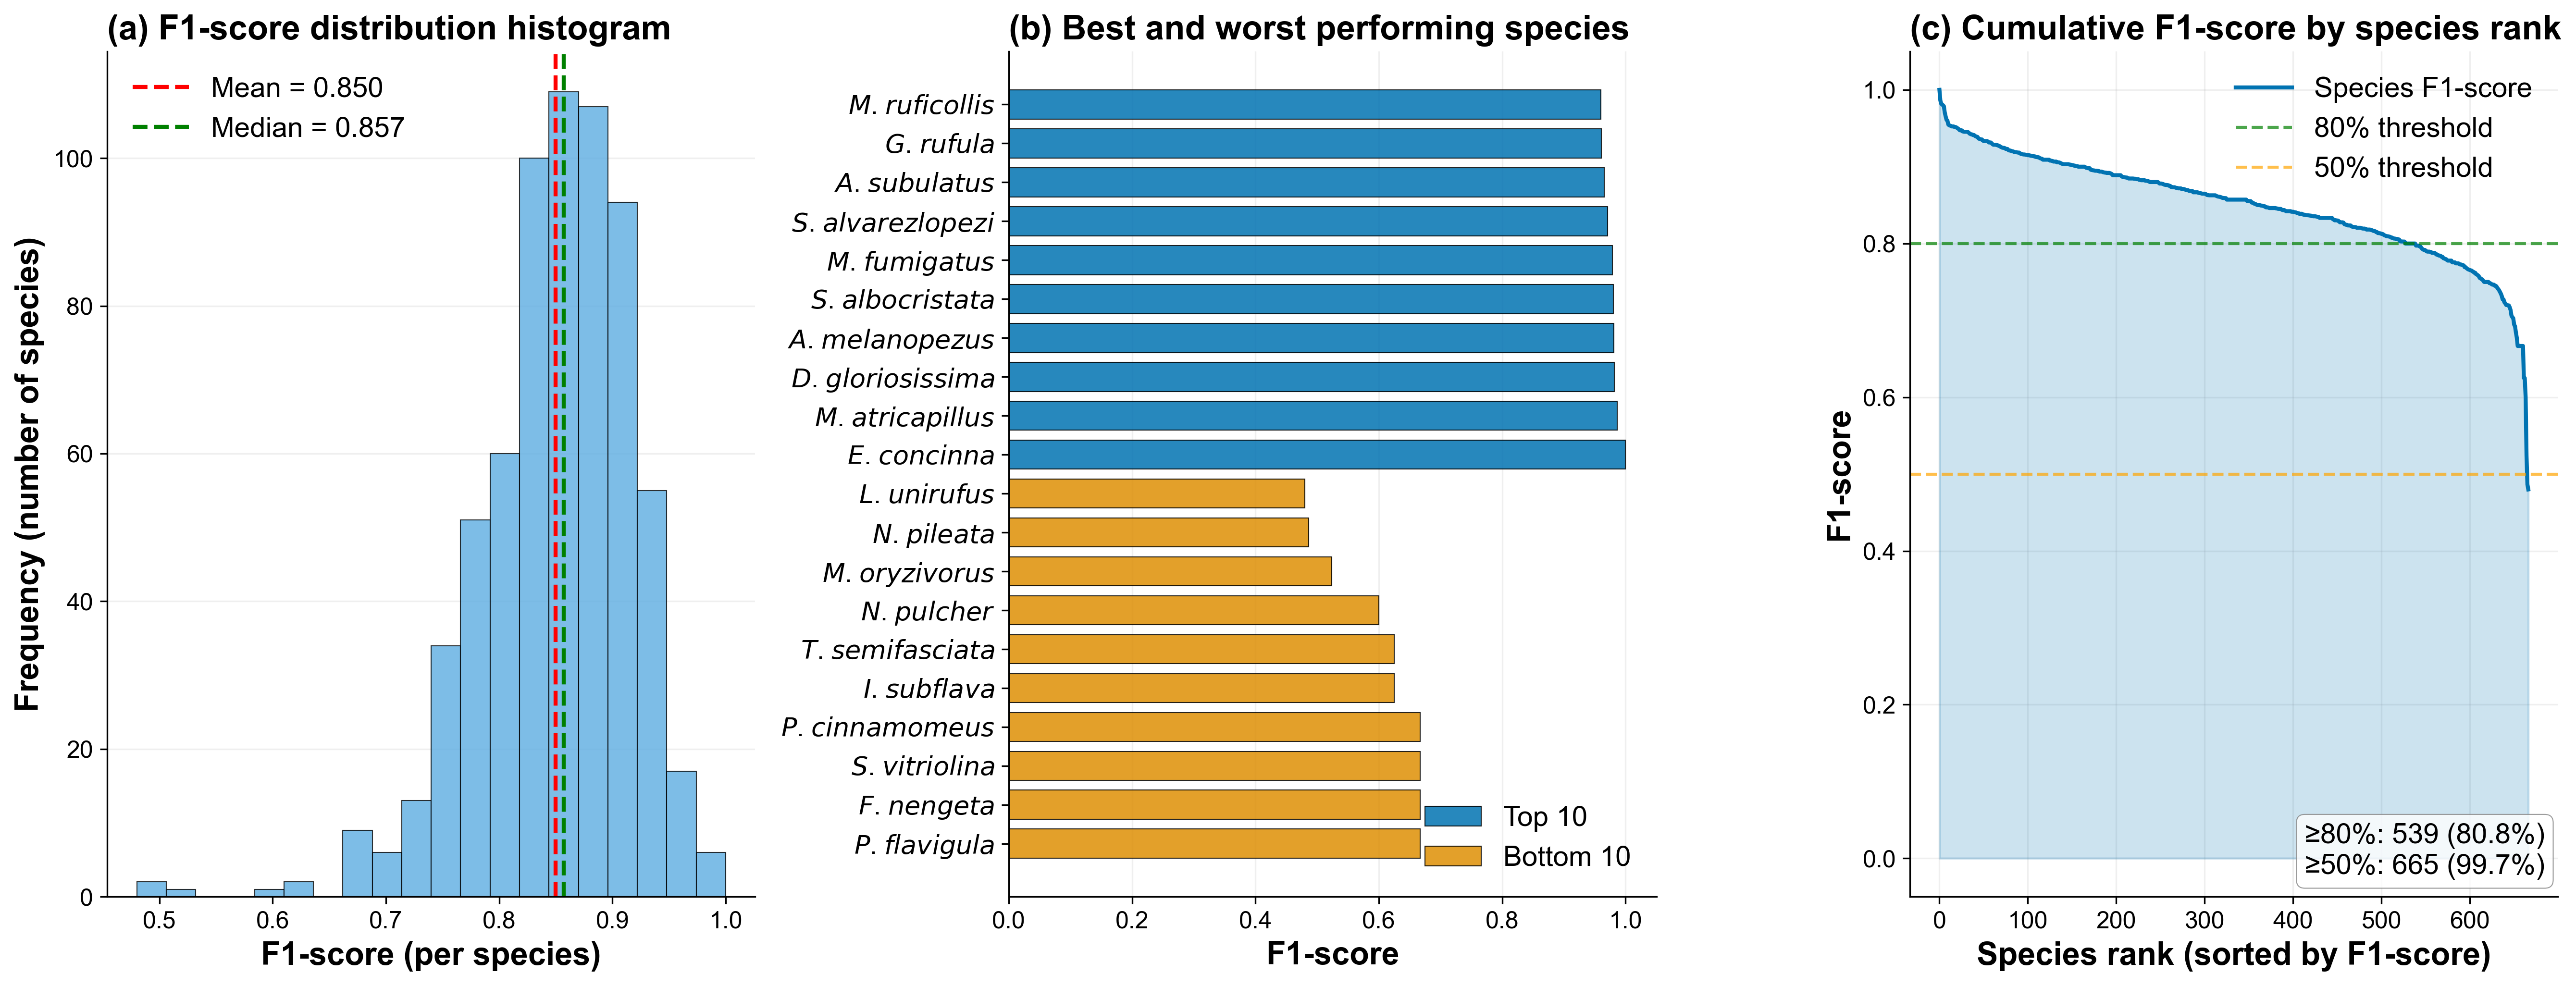

Mean F1=0.850  Median=0.857  >=80%=539 (80.8%)


In [2]:
import re, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

_inc = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv", index_col=0)
def _parse_ints(s): return [int(x) for x in re.findall(r"np\.int64\((\d+)\)", str(s))]

_y_true, _y_pred_mc, _id2sp = [], [], {}
for _sp, _row in _inc.iterrows():
    _real = _parse_ints(_row["clase_real"]); _mc = _parse_ints(_row["predicciones_mc"])
    if _real: _id2sp[_real[0]] = _sp
    _y_true += _real; _y_pred_mc += _mc

_rep = classification_report(_y_true, _y_pred_mc, output_dict=True, zero_division=0)
f1_mc_por_especie = pd.DataFrame(
    [(_sp, _rep[str(_c)]["precision"], _rep[str(_c)]["recall"], _rep[str(_c)]["f1-score"], int(_rep[str(_c)]["support"]))
     for _c, _sp in _id2sp.items() if str(_c) in _rep],
    columns=["especie", "precision", "recall", "f1-score", "support"],
).sort_values("f1-score", ascending=False).reset_index(drop=True)
f1_mc_por_especie.to_csv("../src/data/reporte_mc_resnet.csv", index=False)

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12, "axes.linewidth": 0.8, "figure.dpi": 300, "savefig.dpi": 300, "legend.frameon": False})
df_metric = f1_mc_por_especie.rename(columns={"f1-score": "value"})[["especie", "value"]].sort_values("value", ascending=False).reset_index(drop=True)
def _fmt(s):
    p = s.split(" "); return rf"$\it{{{p[0][0]}}}$. $\it{{{p[1]}}}$" if len(p) >= 2 else rf"$\it{{{s}}}$"

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 7), facecolor="white")
color_high, color_low = "#0173B2", "#DE8F05"
ax1.hist(df_metric["value"], bins=20, color="#5DADE2", alpha=0.8, edgecolor="black", linewidth=0.5)
ax1.axvline(df_metric["value"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {df_metric['value'].mean():.3f}")
ax1.axvline(df_metric["value"].median(), color="green", linestyle="--", linewidth=2, label=f"Median = {df_metric['value'].median():.3f}")
ax1.set_xlabel("F1-score (per species)", fontsize=16, fontweight="bold"); ax1.set_ylabel("Frequency (number of species)", fontsize=16, fontweight="bold")
ax1.set_title("(a) F1-score distribution histogram", fontsize=17, fontweight="bold", loc="left"); ax1.legend(loc="upper left", fontsize=14)
ax1.grid(axis="y", alpha=0.2); ax1.set_axisbelow(True); ax1.spines[["top", "right"]].set_visible(False)
_comb = pd.concat([df_metric.tail(10), df_metric.head(10)]).reset_index(drop=True)
_y = np.arange(len(_comb)); _cols = [color_low if i < 10 else color_high for i in range(len(_comb))]
ax2.barh(_y, _comb["value"], color=_cols, alpha=0.85, edgecolor="black", linewidth=0.5, height=0.75)
ax2.set_yticks(_y); ax2.set_yticklabels([_fmt(s) for s in _comb["especie"]], fontsize=13)
ax2.set_xlabel("F1-score", fontsize=16, fontweight="bold"); ax2.set_title("(b) Best and worst performing species", fontsize=17, fontweight="bold", loc="left")
ax2.grid(axis="x", alpha=0.2); ax2.set_axisbelow(True); ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(handles=[plt.Rectangle((0, 0), 1, 1, fc=color_high, alpha=0.85, ec="black", lw=0.5, label="Top 10"),
                    plt.Rectangle((0, 0), 1, 1, fc=color_low, alpha=0.85, ec="black", lw=0.5, label="Bottom 10")], loc="lower right", fontsize=14)
_ds = df_metric.reset_index(drop=True)
ax3.plot(_ds.index, _ds["value"], color=color_high, linewidth=2, label="Species F1-score")
ax3.fill_between(_ds.index, 0, _ds["value"], color=color_high, alpha=0.2)
ax3.axhline(0.8, color="green", linestyle="--", linewidth=1.5, alpha=0.7, label="80% threshold")
ax3.axhline(0.5, color="orange", linestyle="--", linewidth=1.5, alpha=0.7, label="50% threshold")
ax3.set_xlabel("Species rank (sorted by F1-score)", fontsize=16, fontweight="bold"); ax3.set_ylabel("F1-score", fontsize=16, fontweight="bold")
ax3.set_title("(c) Cumulative F1-score by species rank", fontsize=17, fontweight="bold", loc="left"); ax3.legend(loc="upper right", fontsize=14)
ax3.grid(alpha=0.2); ax3.set_axisbelow(True); ax3.spines[["top", "right"]].set_visible(False)
_n80 = (df_metric["value"] >= 0.8).sum(); _n50 = (df_metric["value"] >= 0.5).sum()
ax3.text(0.98, 0.02, f"≥80%: {_n80} ({100*_n80/len(df_metric):.1f}%)\n≥50%: {_n50} ({100*_n50/len(df_metric):.1f}%)",
         transform=ax3.transAxes, fontsize=14, va="bottom", ha="right",
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray", linewidth=0.5))
plt.tight_layout()
plt.savefig("../fig/species_f1_performance_analysis.png", dpi=300, bbox_inches="tight")
plt.savefig("../fig/species_f1_performance_analysis.pdf", bbox_inches="tight")
plt.show()
print(f"Mean F1={df_metric['value'].mean():.3f}  Median={df_metric['value'].median():.3f}  >=80%={_n80} ({100*_n80/len(df_metric):.1f}%)")

## 3. Matriz de confusión por familia filogenética (reviewer comment 8a)

Dos vistas complementarias de la predicción **determinista**, reordenadas por las 36 familias:

- **667×667 mejorada** (`confusion_matrix_family_blocks`): cada error se dibuja como punto — **rojo** si es intra-familia, **gris tenue** si cruza familias; la línea verde marca la diagonal de aciertos. Los cúmulos rojos dentro de los bloques muestran a simple vista que la confusión se concentra entre parientes.
- **36×36 agregada** (`confusion_matrix_family_aggregated`): colapsa las 667 especies en sus familias. La diagonal es el *family-level recall* (media ≈ 88 %), evidenciando que el modelo casi nunca cruza fronteras de familia.

El **21.7 % de los errores** son intra-familia, ≈ **2.2× más** de lo esperado por azar (10 %) → confusión filogenética (Sección 4.4).

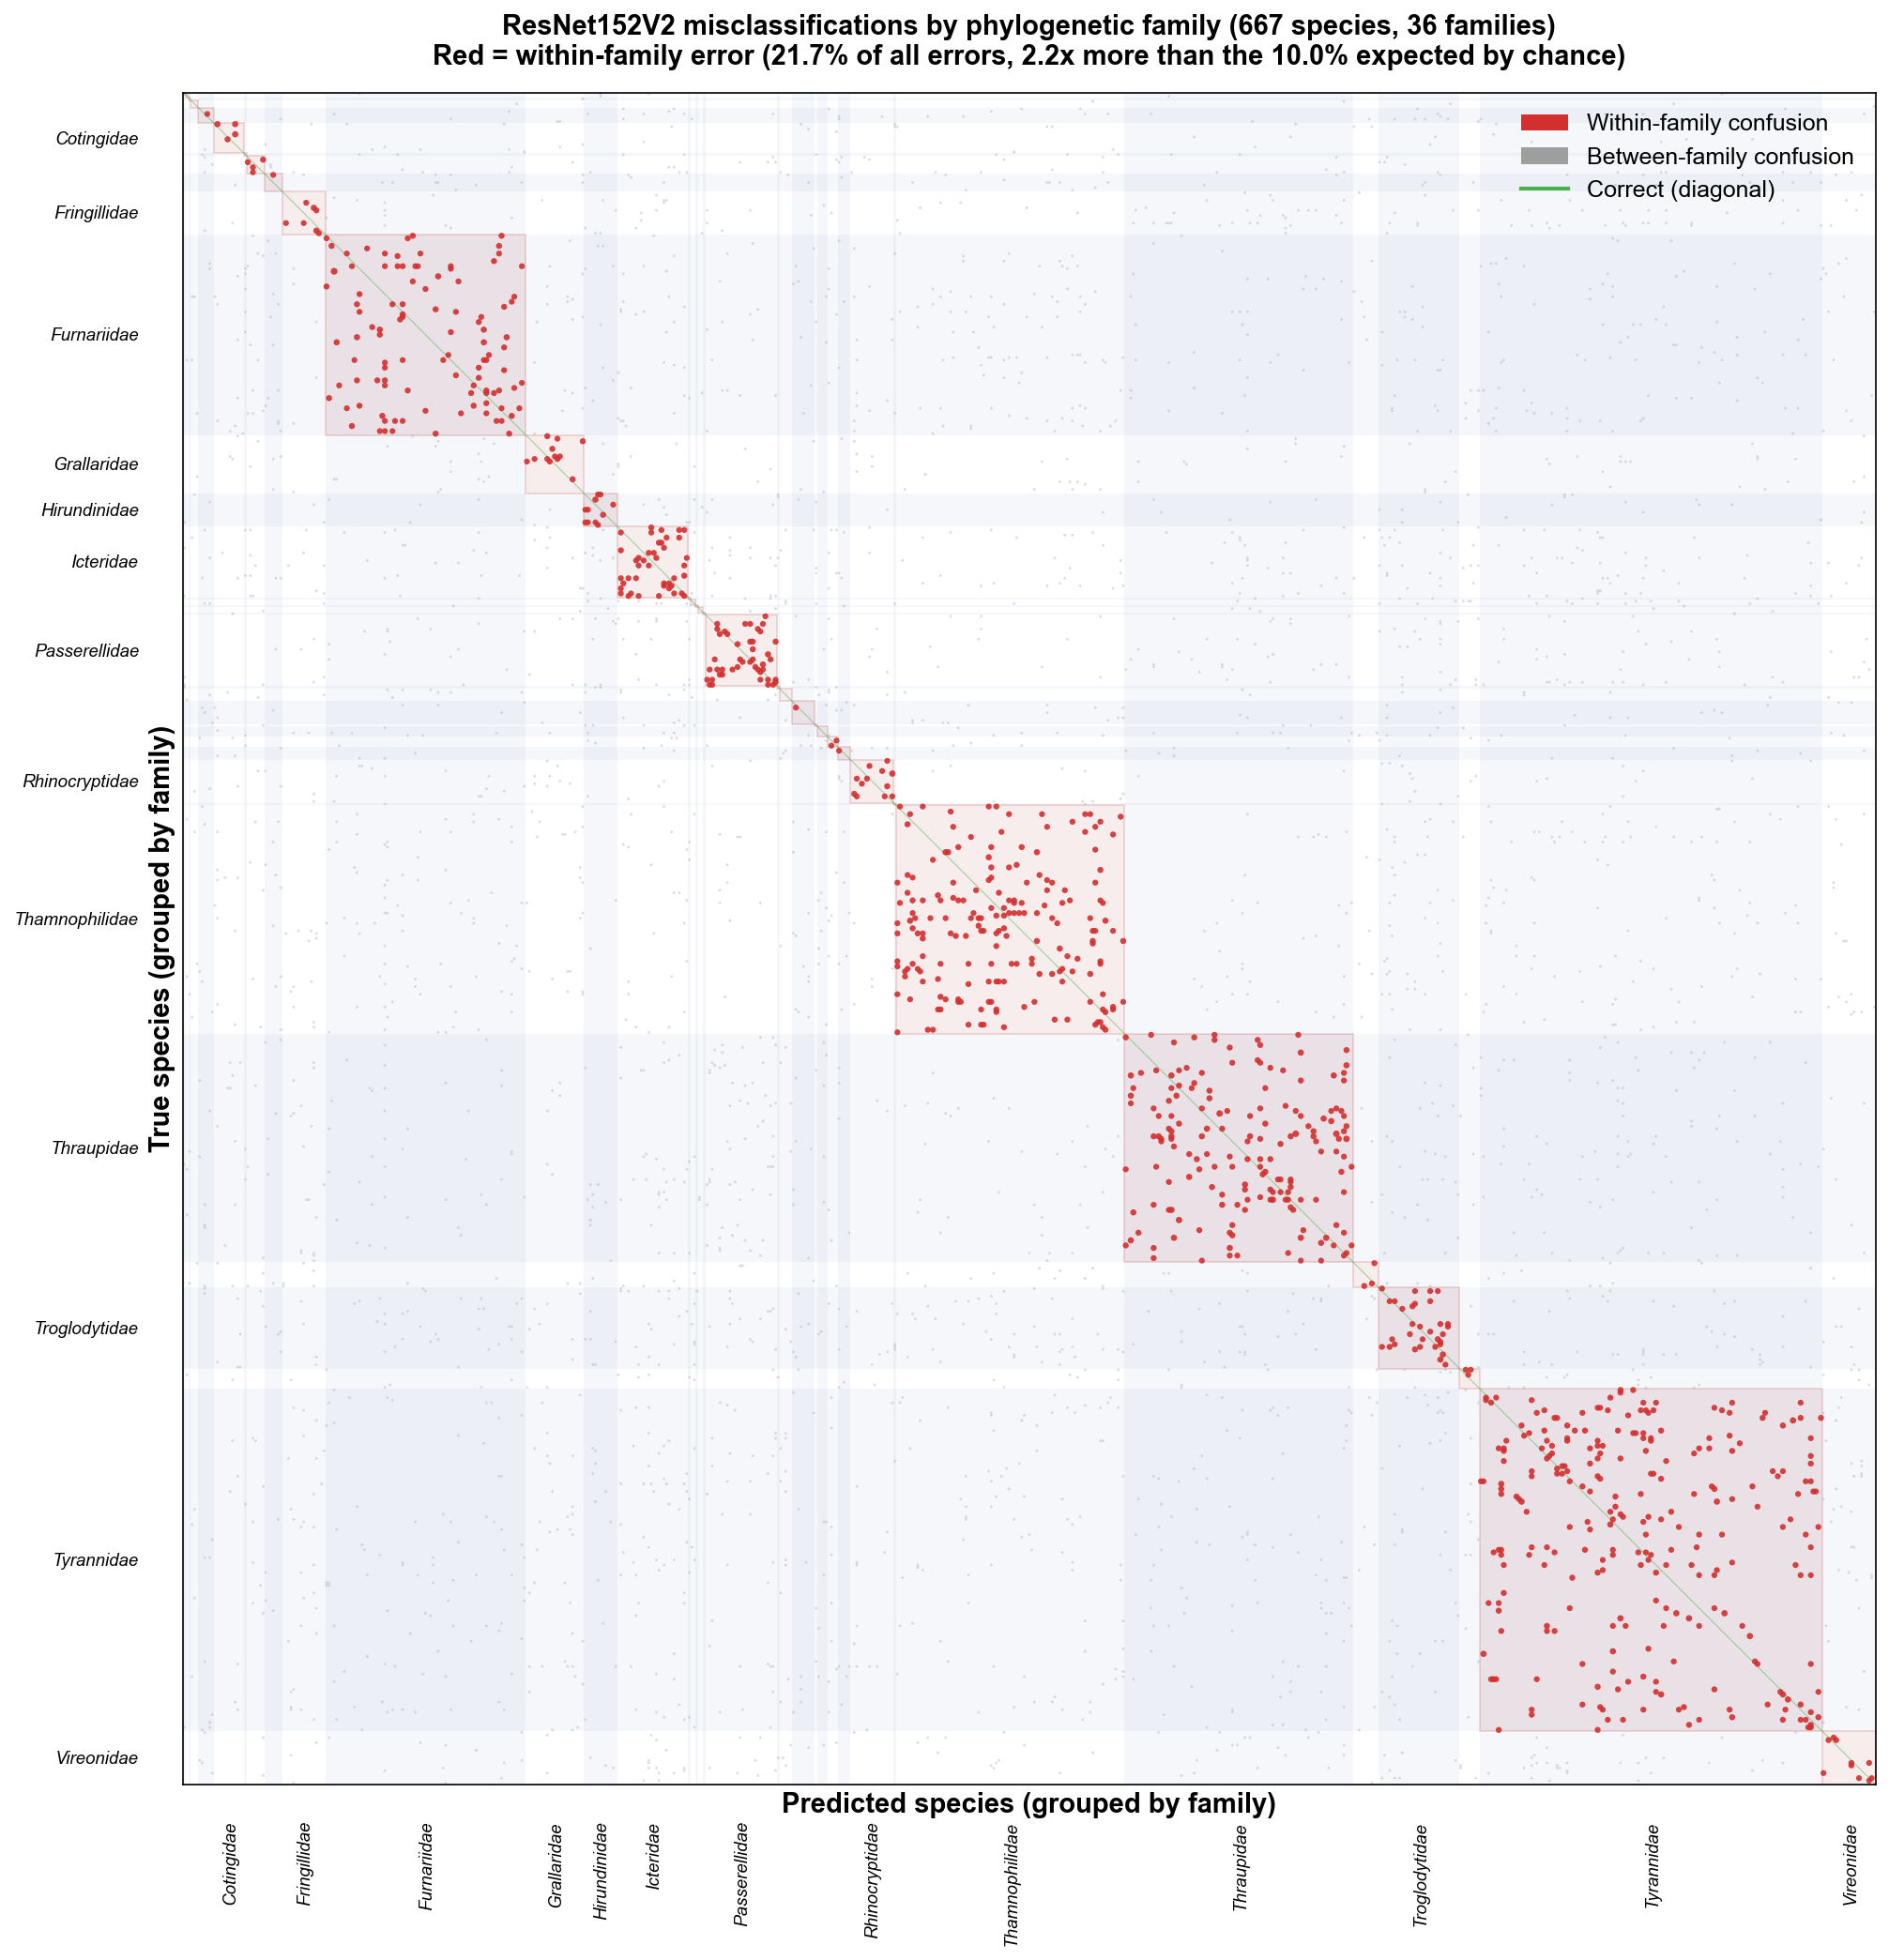

Within-family: 21.7%  | expected by chance: 10.0%  | enrichment: 2.2x


In [15]:
import re, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from sklearn.metrics import confusion_matrix

inc = pd.read_csv("../src/data/incertidumbres_ResNet152V2.csv", index_col=0)
fam = pd.read_csv("../src/data/tabla_confusiones_analisis.csv"); sp2fam = dict(zip(fam["Especie"], fam["Familia"]))
def pints(s): return [int(x) for x in re.findall(r"np\.int64\((\d+)\)", str(s))]
y_true, y_pred, id2sp = [], [], {}
for sp, row in inc.iterrows():
    real = pints(row["clase_real"]); det = pints(row["clase_predicha_inferencia"])
    if real: id2sp[real[0]] = sp
    y_true += real; y_pred += det
y_true = np.array(y_true); y_pred = np.array(y_pred)
ids = sorted(id2sp.keys(), key=lambda c: (sp2fam.get(id2sp[c], "zzz"), id2sp[c]))
order_fam = [sp2fam.get(id2sp[c], "Unknown") for c in ids]; famarr = np.array(order_fam); N = len(ids)
cm = confusion_matrix(y_true, y_pred, labels=ids).astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
bounds = []; start = 0
for i in range(1, len(order_fam) + 1):
    if i == len(order_fam) or order_fam[i] != order_fam[start]: bounds.append((start, i, order_fam[start])); start = i

# metricas: enriquecimiento de la confusion intra-familia sobre el azar
off = cm.copy(); np.fill_diagonal(off, 0)
same = famarr[:, None] == famarr[None, :]
pct_intra = 100 * off[same].sum() / off.sum()
fam_sizes = pd.Series(order_fam).value_counts().to_dict(); epr = off.sum(axis=1)
pct_exp = 100 * np.sum([epr[i] * (fam_sizes[famarr[i]] - 1) / (N - 1) for i in range(N)]) / off.sum()
enrich = pct_intra / pct_exp

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "figure.dpi": 150, "savefig.dpi": 300, "legend.frameon": False})
fig, ax = plt.subplots(figsize=(14, 14), facecolor="white")
for k, (s, e, f) in enumerate(bounds):                        # bandas guia alternadas
    a = 0.05 if k % 2 == 0 else 0.0
    ax.add_patch(Rectangle((s-0.5, -0.5), e-s, N, facecolor="#4C72B0", alpha=a, ec="none", zorder=0))
    ax.add_patch(Rectangle((-0.5, s-0.5), N, e-s, facecolor="#4C72B0", alpha=a, ec="none", zorder=0))
for s, e, f in bounds:                                        # bloque intra-familia resaltado
    ax.add_patch(Rectangle((s-0.5, s-0.5), e-s, e-s, facecolor="#DDA0A0", alpha=0.18, edgecolor="#B22222", lw=0.8, zorder=1))
ii, jj = np.where(off > 0); vals = cm_norm[ii, jj]; intra = famarr[ii] == famarr[jj]
ax.scatter(jj[~intra], ii[~intra], s=6*(0.3+vals[~intra]), c="#9E9E9E", alpha=0.35, ec="none", zorder=2)  # inter-familia (contexto)
ax.scatter(jj[intra], ii[intra], s=22*(0.4+vals[intra]), c="#D32F2F", alpha=0.9, ec="none", zorder=3)      # intra-familia (mensaje)
ax.plot([0, N], [0, N], color="#4CAF50", lw=0.6, alpha=0.45, zorder=1)                                     # aciertos (diagonal)
for s, e, f in bounds:
    if e - s >= 12:
        mid = (s+e)/2
        ax.text(-18, mid, f, ha="right", va="center", fontsize=9, fontstyle="italic")
        ax.text(mid, N+14, f, ha="center", va="top", fontsize=9, rotation=90, fontstyle="italic")
ax.set_xlim(-0.5, N-0.5); ax.set_ylim(N-0.5, -0.5); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Predicted species (grouped by family)", fontsize=14, fontweight="bold")
ax.set_ylabel("True species (grouped by family)", fontsize=14, fontweight="bold")
ax.set_title("ResNet152V2 misclassifications by phylogenetic family (667 species, 36 families)\n"
             f"Red = within-family error ({pct_intra:.1f}% of all errors, {enrich:.1f}x more than the {pct_exp:.1f}% expected by chance)",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(handles=[Patch(facecolor="#D32F2F", label="Within-family confusion"),
                   Patch(facecolor="#9E9E9E", label="Between-family confusion"),
                   plt.Line2D([0], [0], color="#4CAF50", lw=2, label="Correct (diagonal)")], loc="upper right", fontsize=12)
plt.tight_layout()
plt.savefig("../fig/confusion_matrix_family_blocks.png", dpi=300, bbox_inches="tight")
plt.savefig("../fig/confusion_matrix_family_blocks.pdf", bbox_inches="tight")
plt.show()
print(f"Within-family: {pct_intra:.1f}%  | expected by chance: {pct_exp:.1f}%  | enrichment: {enrich:.1f}x")

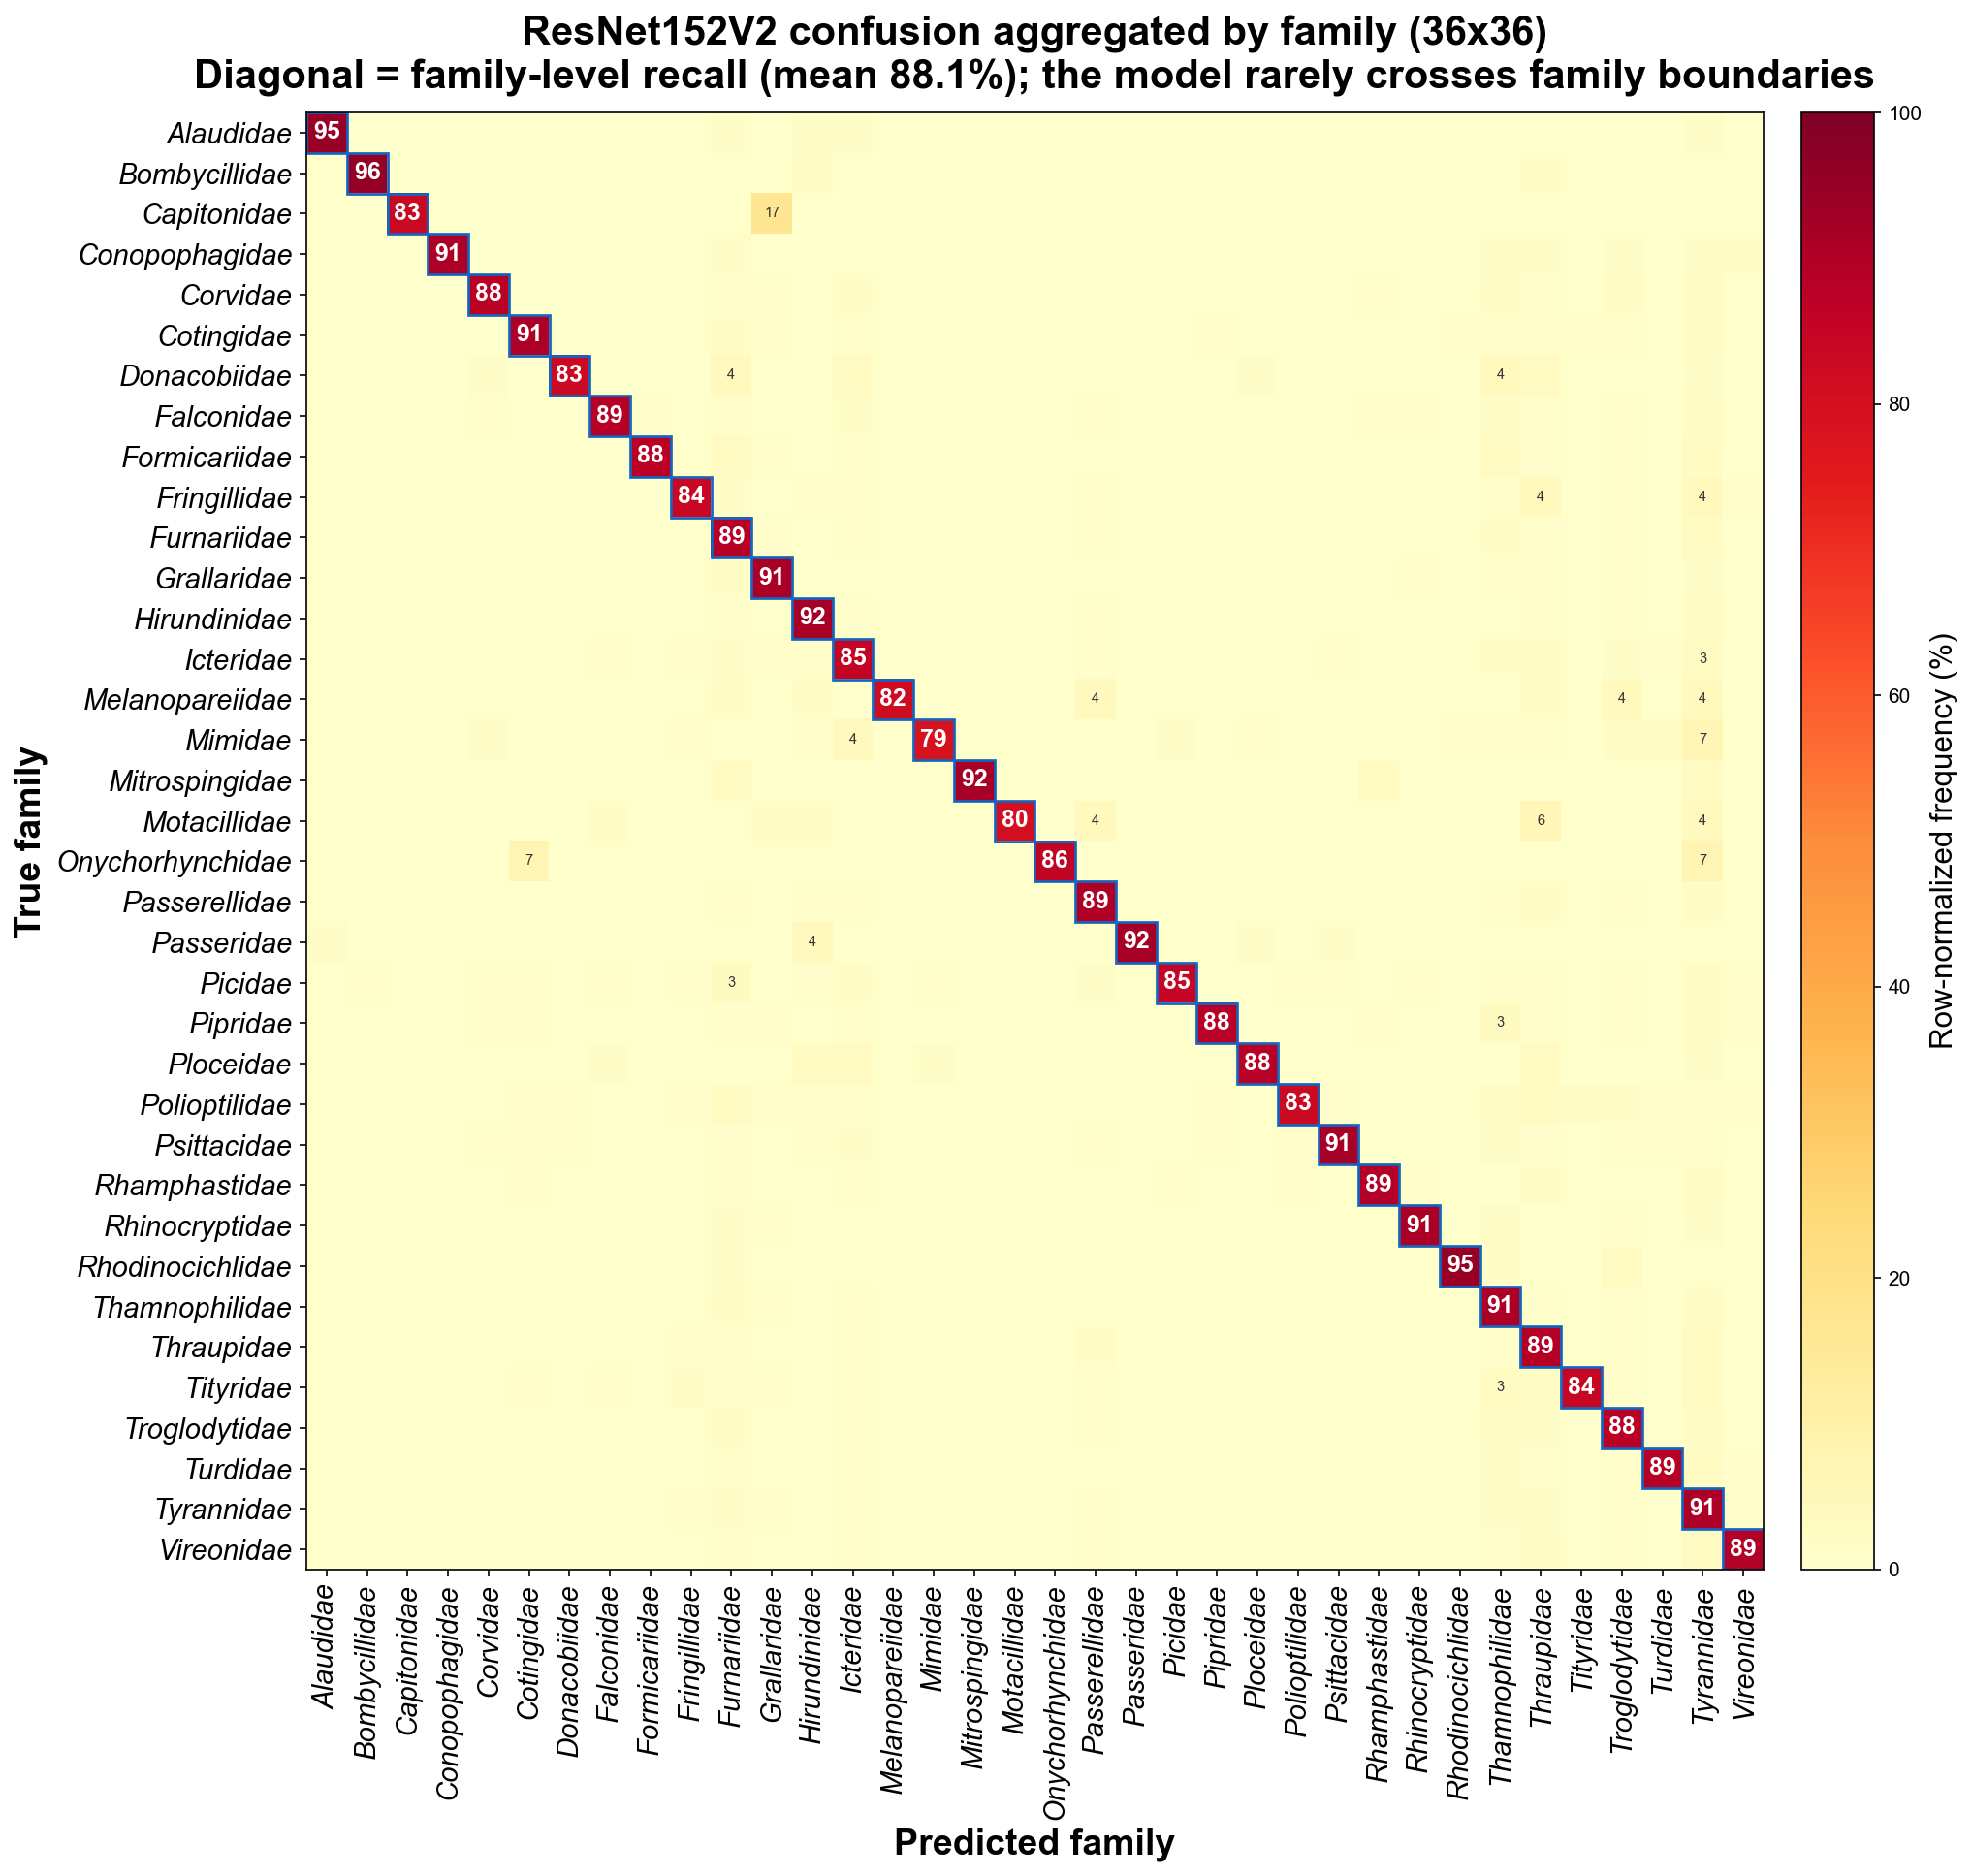

Family-level recall (mean): 88.1%


In [16]:
# Vista agregada 36x36 por familia (reutiliza y_true/y_pred/id2sp/sp2fam/order_fam de la celda anterior)
families = sorted(set(order_fam))
fam_true = np.array([sp2fam.get(id2sp[c], "Unknown") for c in y_true])
fam_pred = np.array([sp2fam.get(id2sp[c], "Unknown") for c in y_pred])
cmf = confusion_matrix(fam_true, fam_pred, labels=families).astype(float)
cmf_norm = 100 * cmf / cmf.sum(axis=1, keepdims=True).clip(min=1); fam_recall = np.diag(cmf_norm)

fig, ax = plt.subplots(figsize=(15, 13), facecolor="white")
im = ax.imshow(cmf_norm, cmap="YlOrRd", vmin=0, vmax=100, aspect="equal")
for i in range(len(families)):
    for j in range(len(families)):
        v = cmf_norm[i, j]
        if i == j:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=12, fontweight="bold", color="white" if v > 55 else "black")
        elif v >= 3:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="#333333")
    ax.add_patch(Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor="#1565C0", lw=1.3))  # resalta diagonal
ax.set_xticks(range(len(families))); ax.set_yticks(range(len(families)))
ax.set_xticklabels(families, rotation=90, fontsize=14, fontstyle="italic"); ax.set_yticklabels(families, fontsize=14, fontstyle="italic")
ax.set_xlabel("Predicted family", fontsize=18, fontweight="bold"); ax.set_ylabel("True family", fontsize=18, fontweight="bold")
ax.set_title("ResNet152V2 confusion aggregated by family (36x36)\n"
             f"Diagonal = family-level recall (mean {fam_recall.mean():.1f}%); the model rarely crosses family boundaries",
             fontsize=20, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label("Row-normalized frequency (%)", fontsize=15)
plt.tight_layout()
plt.savefig("../fig/confusion_matrix_family_aggregated.png", dpi=600, bbox_inches="tight")
plt.savefig("../fig/confusion_matrix_family_aggregated.pdf", bbox_inches="tight")
plt.show()
print(f"Family-level recall (mean): {fam_recall.mean():.1f}%")

## 4. Matriz de confianza bayesiana — MC Dropout (reviewer comment 8b)

**4a. Cálculo (pesado, ~3 h en CPU — correr una sola vez).** Vuelve a pasar las 32,279 imágenes de test por ResNet152V2 con dropout activo, `K` pasadas Monte Carlo, y promedia la probabilidad predictiva por especie → matriz 667×667. Guarda `.npz` y CSV de incertidumbre.

In [ ]:
import os, time, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, tensorflow as tf
import sys; sys.path.insert(0, "../src")
from model_trainer import ModelTrainer

K, BATCH = 5, 128
BASE = "../src/data/images_test/images_spectograms"
species = sorted(d for d in os.listdir(BASE) if os.path.isdir(os.path.join(BASE, d)))
sp2idx = {s: i for i, s in enumerate(species)}; N_CLASSES = len(species)
paths, labels = [], []
for s in species:
    d = os.path.join(BASE, s)
    for f in sorted(os.listdir(d)):
        paths.append(os.path.join(d, f)); labels.append(sp2idx[s])
labels = np.array(labels); N = len(paths)
print(f"Especies={N_CLASSES} imagenes={N} K={K}")

def read_image(p):
    x = tf.io.read_file(p); x = tf.io.decode_jpeg(x, channels=1)
    x = tf.image.resize(x, (128, 256)); return tf.cast(x, tf.float32)
ds = tf.data.Dataset.from_tensor_slices(paths).map(read_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

mt = ModelTrainer(model_name="ResNet152V2"); model = mt.create_model()
model.load_weights("models/weights_ResNet152V2.weights.h5")  # Dropout activo -> cada pasada es muestra MC

prob_sum = np.zeros((N, N_CLASSES), dtype=np.float32)
for k in range(K):
    t = time.time(); idx = 0
    for b in ds:
        p = tf.nn.softmax(model(b, training=True), axis=-1).numpy(); prob_sum[idx:idx+len(p)] += p; idx += len(p)
    print(f"  pasada MC {k+1}/{K} en {(time.time()-t)/60:.1f} min")
prob_mean = prob_sum / K

M = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float32)
for i in range(N_CLASSES):
    m = labels == i
    if m.any(): M[i] = prob_mean[m].mean(axis=0)
diag = np.diag(M); entropy = -np.sum(M * np.log(M + 1e-12), axis=1)
print(f"Accuracy (argmax prob media MC): {(prob_mean.argmax(1)==labels).mean()*100:.2f}%")
print(f"Confianza diagonal media: {diag.mean():.3f} | Entropia media: {entropy.mean():.3f}")
np.savez_compressed("../src/data/bayes_confidence_matrix_ResNet152V2.npz", matrix=M, species=np.array(species), diag=diag, entropy=entropy)
pd.DataFrame({"species": species, "mean_confidence": diag, "predictive_entropy": entropy}).to_csv("../src/data/bayes_uncertainty_per_species.csv", index=False)
print("Guardado npz + csv")

**4b. Graficado (rápido).** Carga el `.npz` ya calculado y dibuja dos vistas de la incertidumbre bayesiana ordenadas por familia:

- **667×667 mejorada** (`bayes_confidence_matrix_family`): capa **cálida** = masa de probabilidad intra-familia, capa **gris** = inter-familia (la diagonal de aciertos se omite para no dominar). La confianza se concentra en los bloques de familia.
- **36×36 agregada** (`bayes_confidence_matrix_aggregated`): probabilidad media por par de familias. La diagonal (≈ **47 %**) es mucho menor que el *family-recall* determinista (≈ **88 %**): bajo incertidumbre calibrada casi la mitad de la masa se reparte fuera de la familia correcta, y esa fuga se concentra en parientes (bloques diagonales).

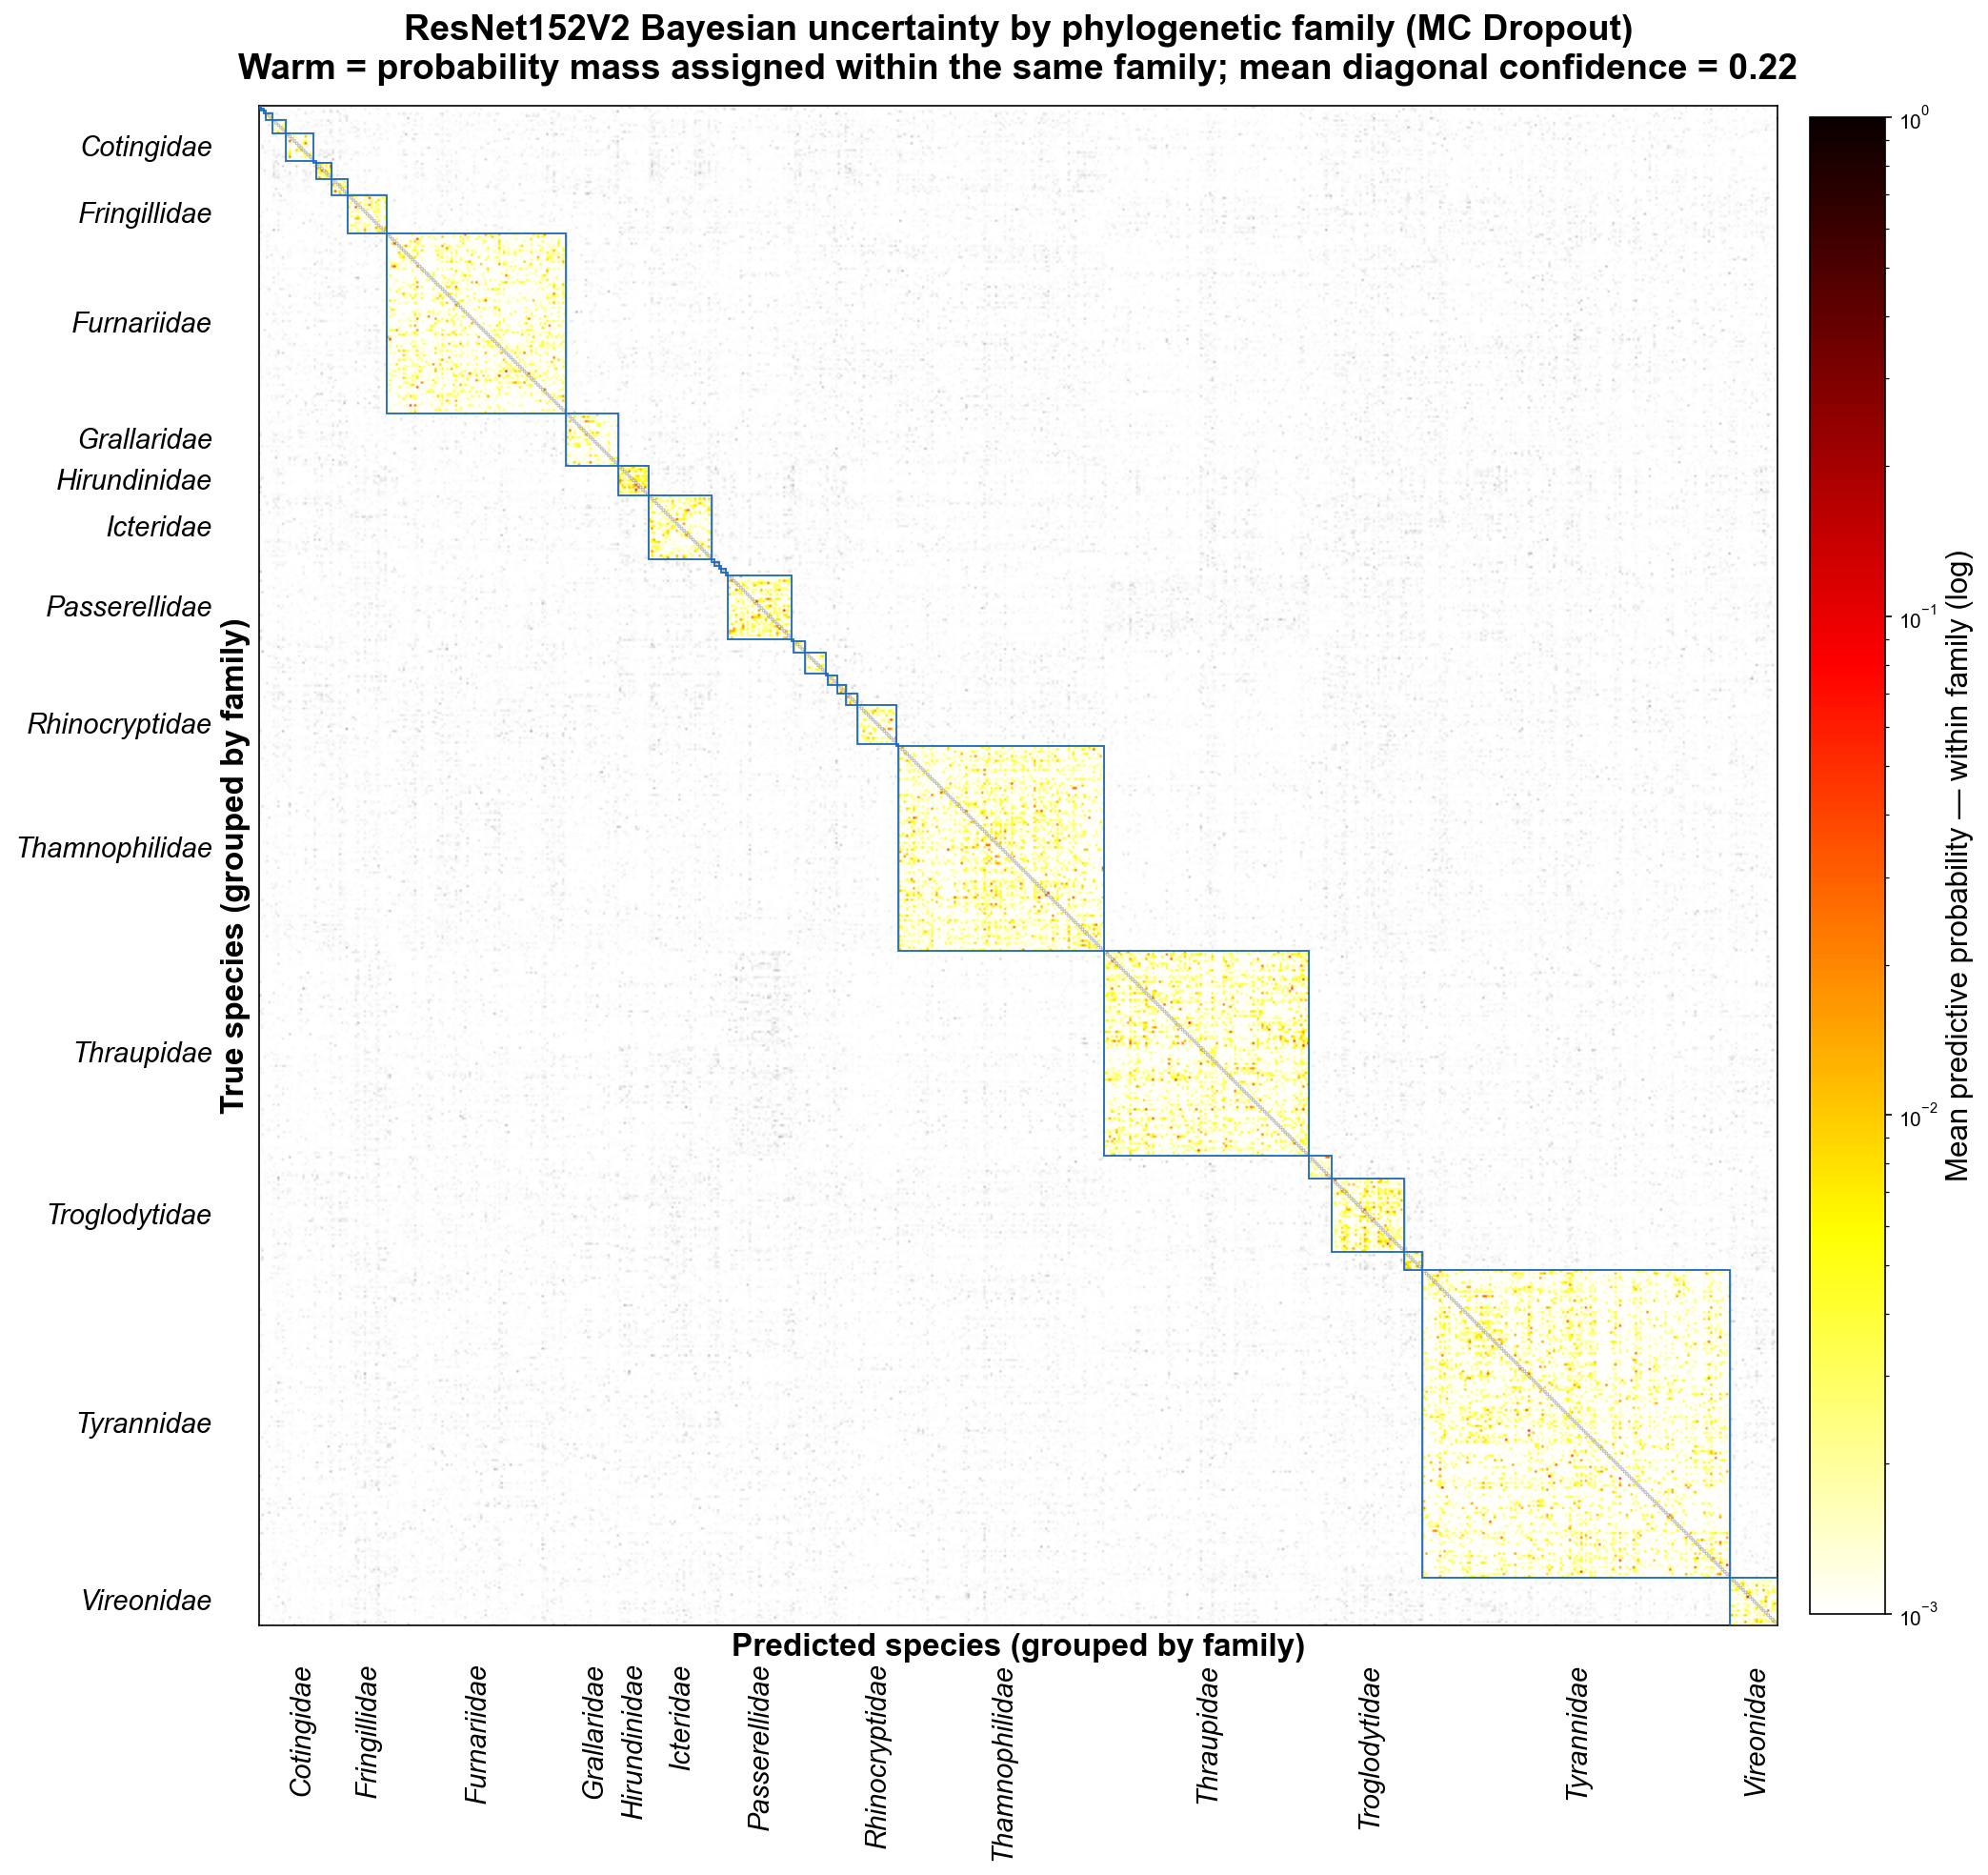

In [17]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

d = np.load("../src/data/bayes_confidence_matrix_ResNet152V2.npz", allow_pickle=True)
M = d["matrix"]; species = list(d["species"]); diag = d["diag"]; NC = len(species)
fam = pd.read_csv("../src/data/tabla_confusiones_analisis.csv"); sp2fam = dict(zip(fam["Especie"], fam["Familia"]))
order = sorted(range(NC), key=lambda i: (sp2fam.get(species[i], "zzz"), species[i]))
Mo = M[np.ix_(order, order)]; ofam = np.array([sp2fam.get(species[i], "Unknown") for i in order])
bnds = []; s = 0
for i in range(1, NC + 1):
    if i == NC or ofam[i] != ofam[s]: bnds.append((s, i, ofam[s])); s = i

# separar masa intra-familia (calida) de inter-familia (gris); omitir diagonal de aciertos
Mo_off = Mo.copy(); np.fill_diagonal(Mo_off, np.nan); same = ofam[:, None] == ofam[None, :]
intra_layer = np.where(same, Mo_off, np.nan); inter_layer = np.where(~same, Mo_off, np.nan)

fig, ax = plt.subplots(figsize=(14, 14), facecolor="white")
ax.imshow(inter_layer, cmap="Greys", norm=LogNorm(vmin=1e-3, vmax=1.0), aspect="equal", alpha=0.55)  # inter-familia
im = ax.imshow(intra_layer, cmap="hot_r", norm=LogNorm(vmin=1e-3, vmax=1.0), aspect="equal")           # intra-familia
for a, b, f in bnds:
    ax.add_patch(Rectangle((a-0.5, a-0.5), b-a, b-a, fill=False, edgecolor="#1565C0", lw=0.9, alpha=0.9, zorder=3))
    if b - a >= 12:
        mid = (a+b)/2
        ax.text(-21, mid, f, ha="right", va="center", fontsize=14, fontstyle="italic")
        ax.text(mid, NC+16, f, ha="center", va="top", fontsize=14, rotation=90, fontstyle="italic")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Predicted species (grouped by family)", fontsize=16, fontweight="bold")
ax.set_ylabel("True species (grouped by family)", fontsize=16, fontweight="bold")
ax.set_title("ResNet152V2 Bayesian uncertainty by phylogenetic family (MC Dropout)\n"
             f"Warm = probability mass assigned within the same family; mean diagonal confidence = {diag.mean():.2f}",
             fontsize=18, fontweight="bold", pad=14)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label("Mean predictive probability — within family (log)", fontsize=15)
plt.tight_layout()
plt.savefig("../fig/bayes_confidence_matrix_family.png", dpi=600, bbox_inches="tight")
plt.savefig("../fig/bayes_confidence_matrix_family.pdf", bbox_inches="tight")
plt.show()

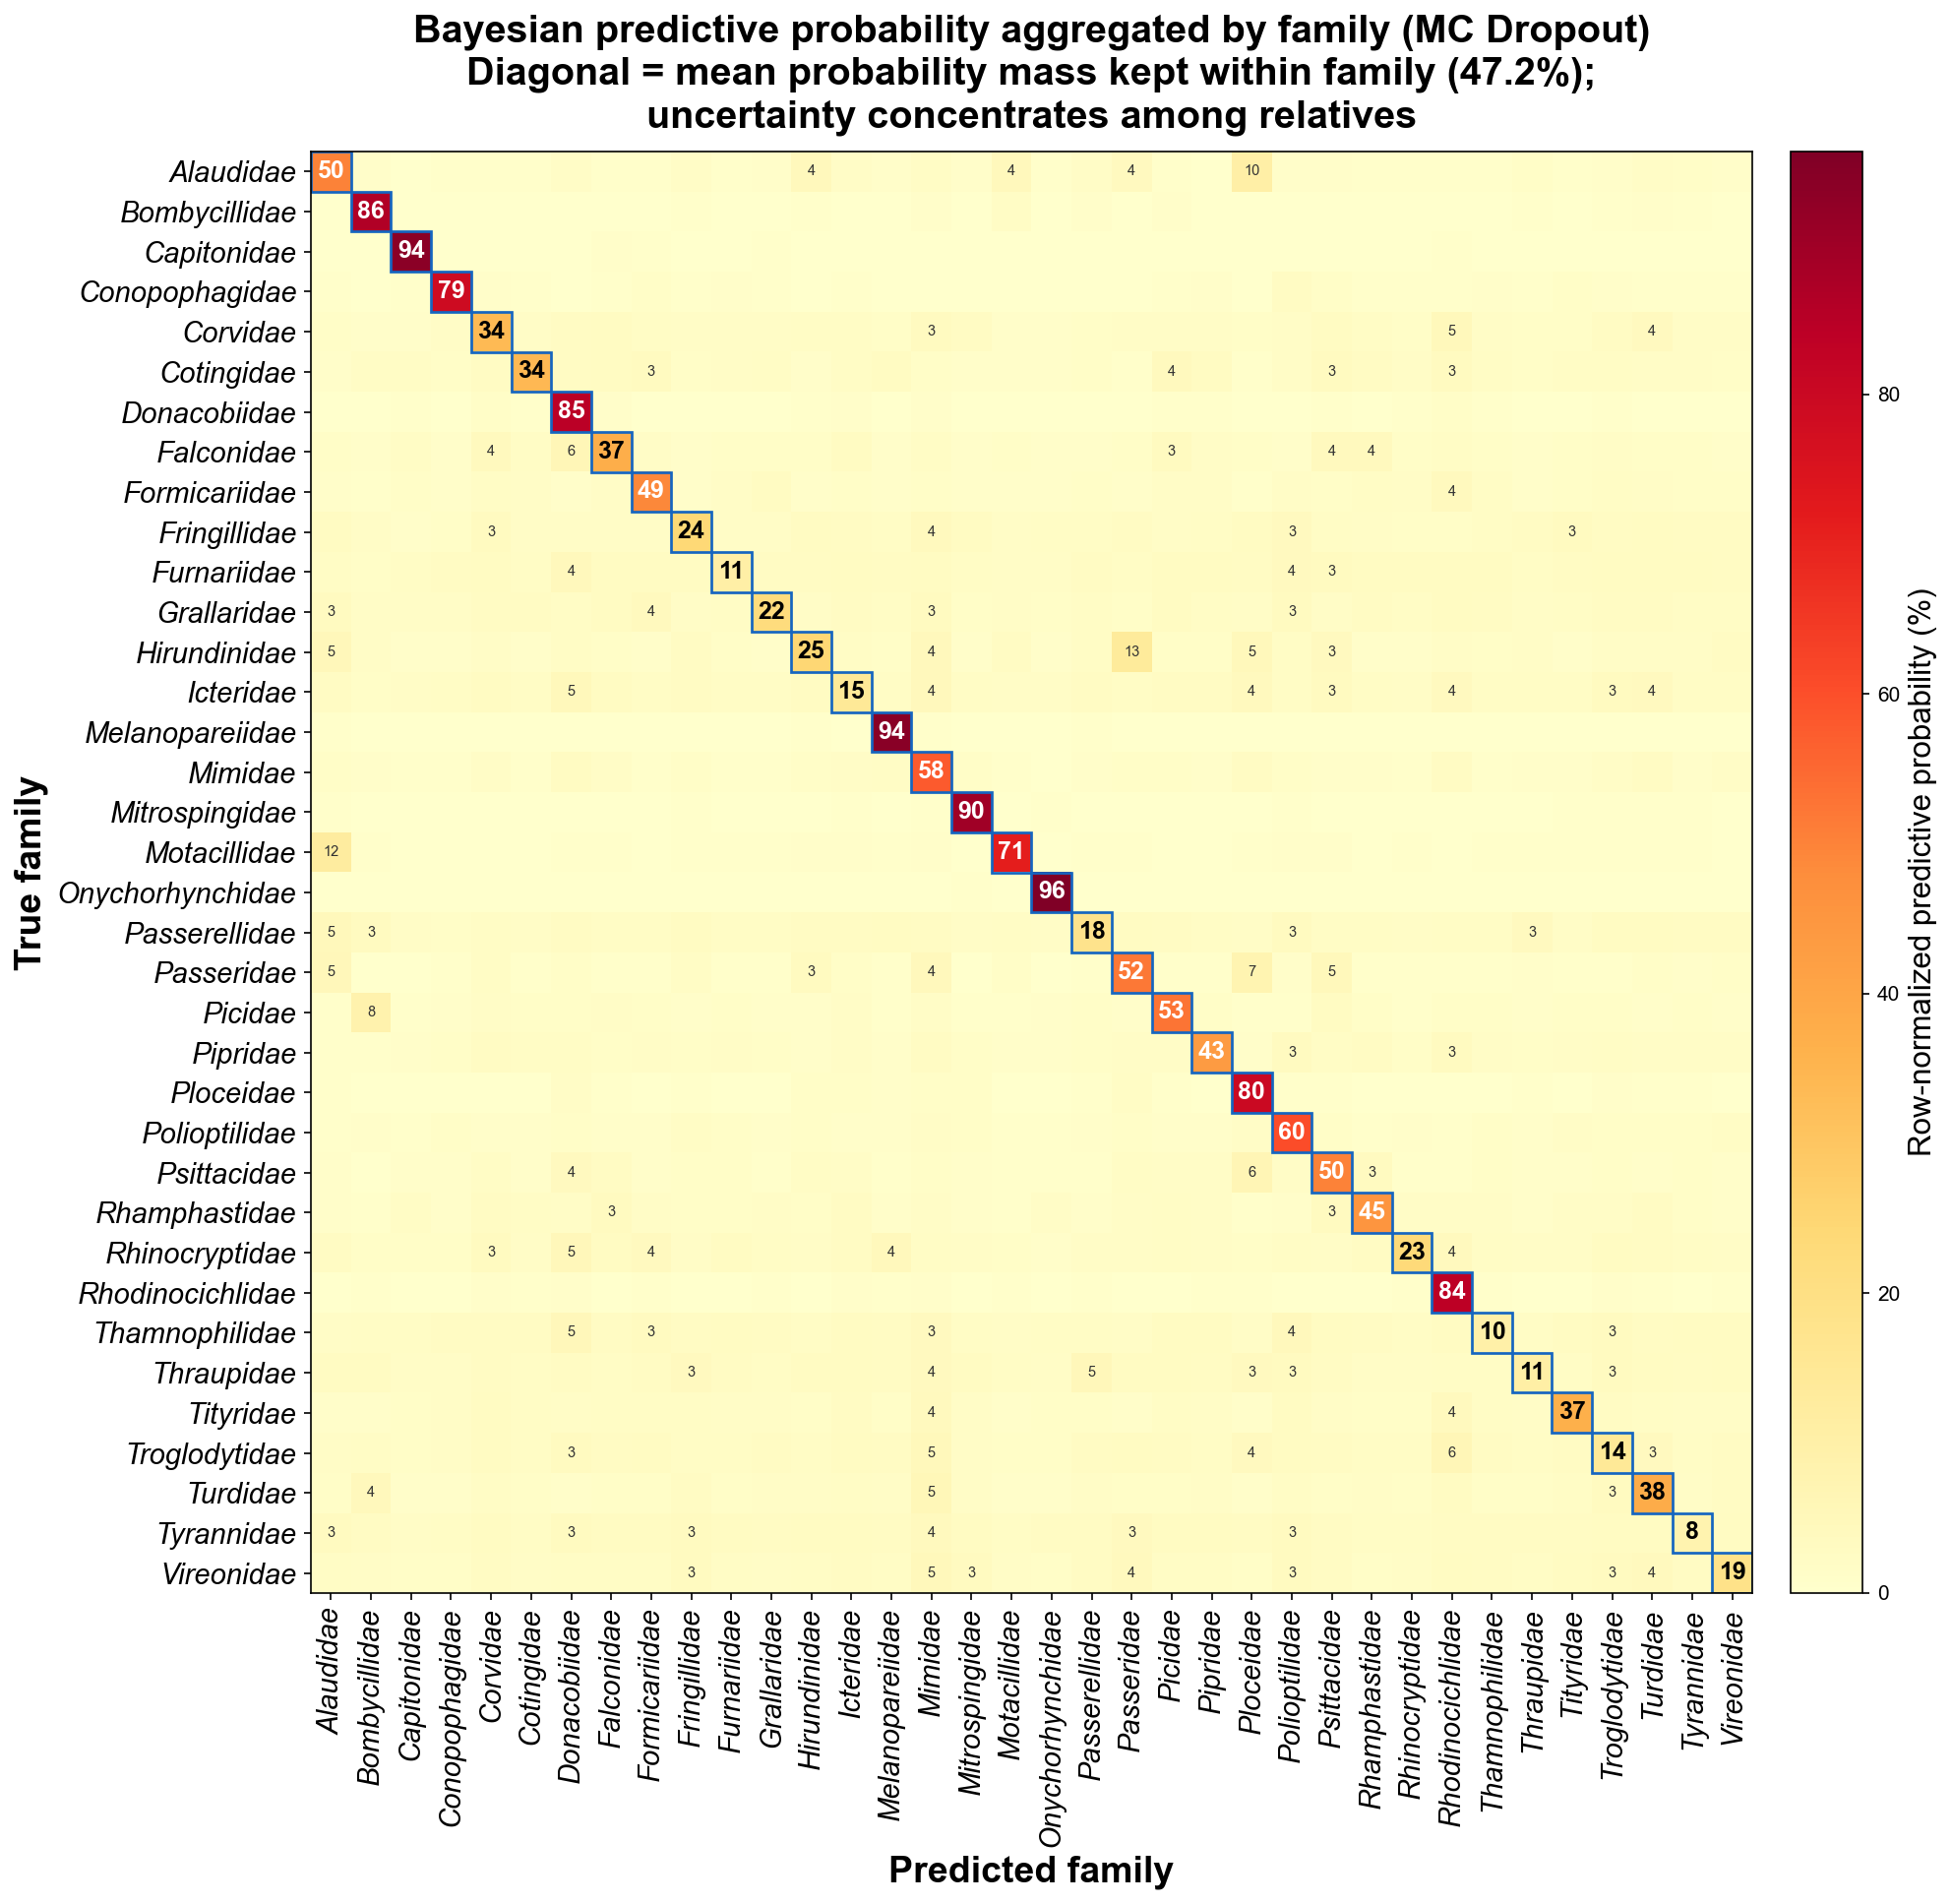

Bayesian within-family probability (mean diagonal): 47.2%  |  vs deterministic family recall ~88%


In [18]:
# Vista agregada 36x36 por familia (reutiliza Mo/ofam de la celda anterior)
fams = sorted(set(ofam)); idx_by = {f: np.where(ofam == f)[0] for f in fams}
Mf = np.array([[Mo[np.ix_(idx_by[fa], idx_by[fb])].mean() for fb in fams] for fa in fams])
Mf_pct = 100 * Mf / Mf.sum(axis=1, keepdims=True).clip(min=1e-9); diag_b = np.diag(Mf_pct)

fig, ax = plt.subplots(figsize=(15, 13), facecolor="white")
im = ax.imshow(Mf_pct, cmap="YlOrRd", vmin=0, vmax=max(60, diag_b.max()), aspect="equal")
for i in range(len(fams)):
    for j in range(len(fams)):
        v = Mf_pct[i, j]
        if i == j:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=12, fontweight="bold", color="white" if v > 40 else "black")
        elif v >= 3:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="#333333")
    ax.add_patch(Rectangle((i-0.5, i-0.5), 1, 1, fill=False, edgecolor="#1565C0", lw=1.3))  # resalta diagonal
ax.set_xticks(range(len(fams))); ax.set_yticks(range(len(fams)))
ax.set_xticklabels(fams, rotation=90, fontsize=14, fontstyle="italic"); ax.set_yticklabels(fams, fontsize=14, fontstyle="italic")
ax.set_xlabel("Predicted family", fontsize=18, fontweight="bold"); ax.set_ylabel("True family", fontsize=18, fontweight="bold")
ax.set_title("Bayesian predictive probability aggregated by family (MC Dropout)\n"
             f"Diagonal = mean probability mass kept within family ({diag_b.mean():.1f}%);\n"
             f"uncertainty concentrates among relatives",
             fontsize=19, fontweight="bold", pad=12)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label("Row-normalized predictive probability (%)", fontsize=15)
plt.tight_layout()
plt.savefig("../fig/bayes_confidence_matrix_aggregated.png", dpi=600, bbox_inches="tight")
plt.savefig("../fig/bayes_confidence_matrix_aggregated.pdf", bbox_inches="tight")
plt.show()
print(f"Bayesian within-family probability (mean diagonal): {diag_b.mean():.1f}%  |  vs deterministic family recall ~88%")